# EDA

In [1]:
import sys
import os

sys.path.append("..")

from src.data_loader import get_cifar10_dataloaders
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# This cell:
# 1. Loads CIFAR-10 train and test dataloaders using our custom pipeline
# 2. Fetches one batch of images + labels
# 3. Prints tensor shapes to validate pipeline integrity

import sys
sys.path.append("..")

import torch
from src.data_loader import get_cifar10_dataloaders

# Load dataloaders
trainloader, testloader = get_cifar10_dataloaders(batch_size=8)

# Get one batch
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Validate structure
print("Image batch shape:", images.shape)  # expected: [8, 3, 32, 32]
print("Labels:", labels)

100%|██████████| 170M/170M [00:32<00:00, 5.17MB/s] 


Image batch shape: torch.Size([8, 3, 32, 32])
Labels: tensor([9, 2, 1, 3, 2, 2, 3, 5])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.8768656].


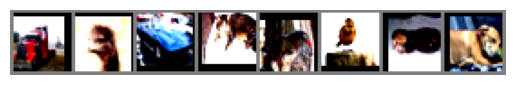

Labels: ['truck', 'bird', 'automobile', 'cat', 'bird', 'bird', 'cat', 'dog']


In [3]:
# This cell:
# 1. Defines CIFAR-10 class labels
# 2. Unnormalizes image tensors for visualization
# 3. Displays a grid of sample images from the batch
# 4. Helps verify that preprocessing + augmentation is visually correct

import matplotlib.pyplot as plt
import numpy as np
import torchvision

classes = (
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
)

def imshow(img):
    # undo normalization approximately for visualization
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")
    plt.show()

# Show batch as grid
imshow(torchvision.utils.make_grid(images))

# Show labels in human-readable form
print("Labels:",
      [classes[i] for i in labels])

In [5]:
# This cell performs a final sanity check on the CIFAR-10 data pipeline:
# 1. Confirms batch loading works without errors
# 2. Verifies tensor value ranges and shapes
# 3. Ensures normalization does not break image structure
# 4. Checks that labels are correctly mapped

import torch

print("Image shape:", images.shape)  # expected: [batch, 3, 32, 32]
print("Label shape:", labels.shape)

# Check tensor value range (post-normalization, values should be small but finite)
print("Min pixel value:", torch.min(images).item())
print("Max pixel value:", torch.max(images).item())

# Check label validity
print("Unique labels in batch:", torch.unique(labels))

Image shape: torch.Size([8, 3, 32, 32])
Label shape: torch.Size([8])
Min pixel value: -2.429065704345703
Max pixel value: 2.7537312507629395
Unique labels in batch: tensor([1, 2, 3, 4, 5, 7, 8, 9])
